<div style="background-color:#d4edda;font-size:19px; color:#155724; padding:18px; border-radius:10px; border:1px solid #c3e6cb; font-family:Arial, sans-serif;">

<center> <b>Réalisé par A-ABO
<br>
<center> Ce projet a été réalisé par un étudiant en 2026.

<br>

<div style="font-size:9px; color:#4a5c4f; font-style:italic; text-align:center;">

<center> Ce projet peut contenir des erreurs.

</div>

</div>

<center> <h2> TD/TME11: SQL et Python 

In [1]:
pip install jaydebeapi JPype1 pandas matplotlib --upgrade --break-system-packages

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 71.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 103.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 79.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 87.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [jaydebeapi]9 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


### Initialisation

On utilise **H2 Database Engine**. Voir la [documentation H2 SQL](https://www.h2database.com/html/commands.html).

Ce TP consiste à réaliser une base de données qui contient des informations géographiques sur des pays, leurs régions et leurs villes ainsi que leurs frontières, les lacs, les mers et les montagnes. 

In [2]:
# Importer les bibliothèques nécessaires
# jaydebeapi : connecteur JDBC pour les bases de données
# pandas : manipulation et analyse de données
# urllib.request : télécharger des fichiers depuis Internet
# os : opérations du système d'exploitation
# sys : paramètres spécifiques au système
import jaydebeapi
import pandas as pd
import urllib.request
import os
import sys

In [3]:
# Créer le dossier local pour stocker les fichiers de la base de données H2
local_dir = "data"
os.makedirs(local_dir, exist_ok=True)  # exist_ok=True évite une erreur si le dossier existe déjà

In [4]:
# Télécharger le driver H2 s'il n'existe pas localement
# Le fichier h2.jar est nécessaire pour la connexion JDBC à H2
if not os.path.exists('h2.jar'):
    urllib.request.urlretrieve('https://repo1.maven.org/maven2/com/h2database/h2/2.2.224/h2-2.2.224.jar', 'h2.jar')

In [5]:
# Créer une connexion JDBC à un serveur H2
# La base de données est créée automatiquement dans le répertoire ./data/test
db = jaydebeapi.connect(
    "org.h2.Driver",  # Pilote H2 pour JDBC
    "jdbc:h2:./data/test;MODE=PostgreSQL",  # URL de connexion avec mode PostgreSQL
    ["sa", "sa"],  # Utilisateur et mot de passe (sa = system admin)
    "h2.jar"  # Chemin du fichier jar du driver
)

**Si la cellule précédente produit une erreur, vous pouvez effacer effacer le répertoire data et recommencer depuis le début**

In [6]:
# Tester la connexion à la base de données avec un curseur explicite
cursor = db.cursor()  # Créer un curseur pour exécuter des commandes SQL
cursor.execute("SELECT 'hello' as col")  # Exécuter une requête simple
cursor.close()  # Fermer le curseur après utilisation
print("Connexion réussie !")

Connexion réussie !


## Les Curseurs SQL

**Description :** Un curseur (cursor) est un objet qui agit comme intermédiaire entre le programme Python et le serveur de base de données. Il permet d'exécuter des commandes SQL et de récupérer les résultats.

**Syntaxe :** `cursor = db.cursor()`

**Fonctionnement :**
- Un curseur est créé à partir d'une connexion (`db`)
- Il permet d'exécuter des requêtes SQL via `cursor.execute()`
- Il permet de récupérer les résultats via `cursor.fetchone()` ou `cursor.fetchall()`
- Il doit être fermé après utilisation avec `cursor.close()`

**Principales méthodes et attributs :**
- `cursor.execute(sql)` : exécute une requête SQL
- `cursor.fetchone()` : récupère une ligne du résultat
- `cursor.fetchall()` : récupère toutes les lignes du résultat
- `cursor.close()` : ferme le curseur
- `cursor.description` : contient le schéma de la réponse (noms et types des colonnes)

### Execution de requêtes SQL : `execute`

**Description :** `cursor.execute()` exécute une requête ou une commande SQL. Cette méthode soumet la requête au serveur SGBD pour exécution. La commande `execute` n'affiche pas de résultat et retourne `None`.

**Syntaxe :** `cursor.execute(sql)` ou `cursor.execute(sql, [paramètres])`

**Paramètres :**
- `sql` : Une chaîne contenant la requête SQL à exécuter
- `paramètres` (optionnel) : Une séquence de valeurs à substituer aux paramètres de la requête (utile pour éviter les injections SQL)

**Retour :** `None`

In [7]:
# Ouvrir un curseur pour exécuter des commandes SQL
cursor = db.cursor()

# Exécuter les ordres SQL pour créer et initialiser la table Compte
cursor.execute("DROP TABLE Compte IF EXISTS")  # Supprimer la table si elle existe
cursor.execute("CREATE TABLE IF NOT EXISTS Compte (nom VARCHAR(50), solde INT, PRIMARY KEY (nom))")  # Créer la table
cursor.execute("TRUNCATE TABLE Compte")  # Vider la table
cursor.execute("INSERT INTO Compte (nom, solde) VALUES ('Alice', 200)")  # Insérer Alice
cursor.execute("INSERT INTO Compte (nom, solde) VALUES ('Bob', 500)")  # Insérer Bob

# Fermer le curseur après utilisation
cursor.close()

# Valider les modifications (commit de la transaction)
db.commit()

#### Exercice: Inserer le compte Tom avec un solde de 900 dans la table Compte

In [ ]:
# Ouvrir un curseur pour exécuter la requête SQL
# Votre code ici

# Insérer un nouveau compte pour Tom avec un solde de 900
# Votre code ici

# Fermer le curseur
# Votre code ici

### Lire le résultat d'une requête : `fetchone` et `fetchall` 

#### cursor.fetchone()
**Description :** `cursor.fetchone()` récupère la prochaine (première) ligne du résultat d'une requête et la retourne sous forme de tuple. Si aucune ligne n'est disponible, elle retourne `None`.

**Syntaxe :** `row = cursor.fetchone()`

**Retour :** Un tuple représentant une ligne du résultat, ou `None` s'il n'y a plus de lignes disponibles.

### fetchone

In [ ]:
# Ouvrir un curseur pour exécuter la requête
cursor = db.cursor()

# Exécuter une requête SELECT pour récupérer les comptes triés par solde décroissant
cursor.execute("SELECT * FROM Compte ORDER BY solde DESC")

# Afficher la première ligne
print("Première réponse :")
print(cursor.fetchone())

# Afficher les lignes suivantes avec une boucle
print("\nLes réponses suivantes :")
ligne = cursor.fetchone()
while ligne is not None:
    print(ligne)
    ligne = cursor.fetchone()

# Démontrer qu'il n'y a plus de réponses
print("\nIl n'y a plus de réponses :")
print(cursor.fetchone())  # Retourne None

cursor.close()

#### Exercice: Affichez le compte avec le plus petit solde en utilisant fetchone() et sans changer la requête

        ('Alice', 200)

In [ ]:
# Exercice : Afficher le compte avec le plus petit solde en utilisant fetchone()
# Ouvrir un curseur
cursor = db.cursor()

# Exécuter une requête SQL (triée par solde décroissant)
cursor.execute("SELECT * FROM Compte ORDER BY solde DESC")

# ... votre code ici ...

#### cursor.fetchall()

**Description :** `cursor.fetchall()` récupère toutes les lignes restantes du résultat d'une requête et les retourne sous forme de liste de tuples. Si aucune ligne n'est disponible, elle retourne une liste vide.

**Syntaxe :** `rows = cursor.fetchall()`

**Retour :** Une liste de tuples, où chaque tuple représente une ligne du résultat. Retourne une liste vide si aucune ligne n'est disponible.



In [ ]:
# Ouvrir un curseur et exécuter une requête pour récupérer tous les comptes
cursor = db.cursor()
cursor.execute("SELECT * FROM Compte")
reponse = cursor.fetchall()  # Récupérer toutes les lignes d'un coup
print(reponse)


In [ ]:
# Le résultat de la requête a déjà été récupéré, il n'y a plus de réponses
# fetchall() retourne une liste vide car on a déjà récupéré tous les résultats
reponse = cursor.fetchall()
print(reponse)  # Affiche une liste vide []
cursor.close()

### Lire la description (schéma) du résultat : `description`

**Description :** `cursor.description` est un attribut en lecture seule qui fournit des métadonnées sur les colonnes du résultat d'une requête SQL. Il retourne une liste de tuples décrivant chaque colonne.

**Syntaxe :** `cursor.description`

**Retour :** Une liste de tuples, où chaque tuple contient les informations suivantes pour une colonne :
- Nom de la colonne (index 0)
- Type de la colonne (index 1)
- Taille pour affichage (index 2)
- Taille interne (index 3)
- Précision (index 4)
- Échelle (index 5)
- Nullabilité (index 6) : 0=NOT NULL, 1: NULL possible

**Note :** `cursor.description` n'est disponible que après une requête SELECT. Il est utile pour connaître la structure des données sans avoir à les parcourir.

In [ ]:
# Accéder à cursor.description qui contient les métadonnées des colonnes du résultat
cursor = db.cursor()
cursor.execute("SELECT * FROM Compte")
# Parcourir et afficher les informations sur chaque colonne
for i in cursor.description:
    print(i)  # Affiche un tuple avec (nom_colonne, type, ...)
cursor.close()

#### Exercice: Affichez la liste des attributs retournés par la requête

    NOM
    SOLDE

In [ ]:
# Exercice : Afficher la liste des attributs (noms de colonnes) retournés par la requête
cursor = db.cursor()
cursor.execute("SELECT * FROM Compte")
# Afficher uniquement les noms de colonnes (index 0 de cursor.description)

# Votre code ici

# Fermer le curseur
cursor.close()

#### Exercice: Affichez le resultat retournés par la requête sous la forme suivante:

    NOM:Alice SOLDE:500 
    NOM:Bob SOLDE:500 
    NOM:Tom SOLDE:900 

In [ ]:
# Exercice : Afficher le résultat sous forme formatée
# Utiliser cursor.description pour extraire les noms de colonnes
cursor = db.cursor()
cursor.execute("SELECT * FROM Compte")

# Votre code ici

cursor.close()

#### Fonction `affiche(curseur)` qui affiche le résultat retourné sous forme d'un curseur

In [ ]:
# Fonction affiche(cursor) : affiche les résultats d'une requête sous forme d'un tableau formaté
def affiche(cursor):
    # Extraire les noms et largeurs des colonnes à partir de cursor.description
    colonnes = [desc[0] for desc in cursor.description]
    largeurs = [max(len(desc[0])+1, min(desc[2]+1, 16)) for desc in cursor.description]
    
    # Créer et afficher l'en-tête du tableau
    en_tete = "".join(str(col)[:largeurs[i]].ljust(largeurs[i]) for i, col in enumerate(colonnes))
    print(en_tete)
    print("-" * (sum(largeurs)))  # Ligne de séparation

    # Afficher les données ligne par ligne
    ligne = cursor.fetchone()
    while ligne is not None:
        ligne_str = "".join(str(valeur)[:largeurs[i]-1].ljust(largeurs[i]) for i, valeur in enumerate(ligne))
        print(ligne_str)
        ligne = cursor.fetchone()

In [ ]:
# Tester la fonction affiche() avec les données de la table Compte
cursor = db.cursor()
cursor.execute("SELECT * FROM Compte")
affiche(cursor)  # Afficher le résultat formaté
cursor.close()

## Les Exceptions 

Le serveur peut déclencher des exceptions qui peuvent être "attrapées" (try-exception) 

In [ ]:
# Démonstration du traitement des exceptions : exécuter une requête avec une erreur de syntaxe
cursor = db.cursor()
try:
    # Cette requête est incorrect : les colonnes A et B n'existent pas
    cursor.execute("SELECT A,B FROM Compte")
    affiche(cursor)
except Exception as e:
    # Attraper et afficher l'erreur
    print(f"-> Exception attrapée : {e}")
cursor.close()

#### Exercice : Insérer dans l'ordre des soldes pour Mary et Alice dans la table Compte et affichez un message d'erreur généré.

    -> Exception attrapée : org.h2.jdbc.JdbcSQLIntegrityConstraintViolationException: Violation d'index unique ou clé primaire: "PUBLIC.PRIMARY_KEY_7 ON PUBLIC.COMPTE(NOM) VALUES ( /* 1 */ 'Alice' )"
    Unique index or primary key violation: "PUBLIC.PRIMARY_KEY_7 ON PUBLIC.COMPTE(NOM) VALUES ( /* 1 */ 'Alice' )"; SQL statement:
    INSERT INTO Compte (nom, solde) VALUES ('Alice', 300) [23505-224]

In [ ]:
# Exercice : Insérer deux nouvelles lignes et observer l'exception

# Votre code ici

cursor.close()


#### Exercice : Affichez le contenu de la table Compte après l'exécution de le cellule précédente. Qu'est-ce que vous observez ?

        NOM             SOLDE       
        ----------------------------
        Alice           200         
        Bob             500         
        Tom             900         
        Mary            800         

In [ ]:
# Exercice : Afficher le contenu de la table Compte après l'exécution de la cellule précédente

# Votre code ici

## L'Atomicité des Transactions (BEGIN, COMMIT, ROLLBACK)
Le concept d'atomicité garantit que toutes les requêtes d'une transaction s'exécutent entièrement, ou sont annulées en bloc en cas d'erreur.

Quand on se connecte à une base de données, on démarre une transaction.

Début et fin de transactions:
- db.commit() : toutes les modifications depuis le dernier commit ou rollback sont **validées** (fin de transaction) et on commence une nouvelle transaction
- db.rollback() : toutes les modifications depuis le dernier commit ou rollback sont **annulées** (fin de transaction) et on commence june nouvelle transaction 

Mode autocommit '(SQL):
- SET AUTOCOMMIT ON : chaque modification est validée instantemment (s'il n'y pas d'erreur)
- SET AUTOCOMMIT OFF : toutes les modifications depuis le dernier commit/rollback ne sont validés/invalidés jusqu'au commit/rollback suivant
    



### Exemple Atomicité

In [ ]:
# Démonstration du ROLLBACK : simulation d'un virement échoué
cursor = db.cursor()

# Commencer une nouvelle transaction
db.commit()
cursor.execute("SET AUTOCOMMIT OFF")

# Afficher l'état de la table avant le virement
print("\n--- ÉTAT DE LA TABLE COMPTE AVANT LE VIREMENT ---")
cursor.execute("SELECT * FROM Compte")
affiche(cursor)

# Simulation d'un échec (ROLLBACK)
print("\n--- TENTATIVE DE VIREMENT (ÉCHEC) ---")
try:
    cursor.execute("SET AUTOCOMMIT OFF")
    # Retirer 100€ à Alice
    cursor.execute("UPDATE Compte SET solde = solde - 100 WHERE nom = 'Alice'")
    print("-> 100€ retirés à Alice...")
    cursor.execute("SELECT * FROM Compte")
 
    # Simuler une panne
    print("-> PANNE CRITIQUE !")
    raise Exception("Panne de courant avant le dépôt !")
 
    # Ce code ne s'exécutera pas
    cursor.execute("UPDATE Compte SET solde = solde + 100 WHERE nom = 'Bob'")
    db.commit()
except Exception as e:
    # En cas d'erreur, annuler toutes les modifications de la transaction
    print(f"-> Exception attrapée : {e}")
    print("-> Annulation de la transaction (ROLLBACK) pour revenir à l'état avant le début de transaction")
    db.rollback()

# Afficher l'état après le ROLLBACK
print("\n--- ÉTAT DE LA TABLE COMPTE APRÈS ROLLBACK ---")
cursor.execute("SELECT * FROM Compte")
affiche(cursor)


### Exercice: Insérer dans l'ordre des soldes pour Paul et Alice dans la table Compte et affichez un message d'erreur généré. On veut que les deux insertions réussissent ou aucune. Affichez la table Compte avant et après l'insertion.


    NOM             SOLDE       
    ----------------------------
    Alice           200         
    Bob             500         
    Tom             900         
    Mary            800         
    -> Exception attrapée : org.h2.jdbc.JdbcSQLIntegrityConstraintViolationException: Violation d'index unique ou clé primaire: "PUBLIC.PRIMARY_KEY_7 ON PUBLIC.COMPTE(NOM) VALUES ( /* 1 */ 'Alice' )"
    Unique index or primary key violation: "PUBLIC.PRIMARY_KEY_7 ON PUBLIC.COMPTE(NOM) VALUES ( /* 1 */ 'Alice' )"; SQL statement:
    INSERT INTO Compte (nom, solde) VALUES ('Alice', 300) [23505-224]
    NOM             SOLDE       
    ----------------------------
    Alice           200         
    Bob             500         
    Tom             900         
    Mary            800      

In [ ]:
# Exercice : Insérer deux comptes de manière atomique (tout ou rien)
cursor = db.cursor()
db.autocommit = False  # Désactiver l'autocommit
db.commit()  # Commencer une nouvelle transaction

# Afficher l'état avant insertion
cursor.execute("SELECT * FROM Compte")
affiche(cursor)

# Insérer deux comptes (le second insertion échouera)

# Votre code ici

# Afficher la table Compte après l'insertion
cursor.execute("SELECT * FROM Compte")
affiche(cursor)
cursor.close()

# Valider les modifications (démarrer une nouvelle transaction pour les prochaines opérations)
db.commit()
cursor.close()

## Fermer la connexion

In [ ]:
# Fermer la connexion à la base de données
db.close()

# La BD Mondial

Ce TP consiste à réaliser une base de données qui contient des informations géographiques sur des pays, leurs régions et leurs villes ainsi que leurs frontières, les lacs, les mers et les montagnes. 

Voici quelques informations supplémentaires sur les données :
* Chaque pays a un nom, un code identifiant, une capitale (avec sa région), une surface, sa population actuelle et au moins une région.
* Les régions sont identifiées par leur nom et le code de leur pays.
* Les montagnes, les lacs, les rivières et les mers sont identifiés par leur nom.
* Les villes sont identifiées par leur nom et leur région.



In [ ]:
# Créer une connexion JDBC à un serveur H2 pour la base de données Mondial
# Cette base de données contient des informations géographiques
db = jaydebeapi.connect(
    "org.h2.Driver",  # Pilote H2
    "jdbc:h2:./data/mondial;MODE=PostgreSQL",  # URL de connexion pour la BD Mondial
    ["sa", "sa"],  # Identifiants
    "h2.jar"  # Fichier jar du driver
)

### Effacer le schéma
Les scripts SQL suivants définissent le schéma et insèrent les données (Base Mondial).

In [ ]:
# Supprimer tous les objets de la base de données (tables, index, etc.)
cursor = db.cursor()
cursor.execute("DROP ALL OBJECTS")  # Commande H2 pour tout supprimer
cursor.close()

### Créér le schéma

In [ ]:
# Lire et exécuter le script de création du schéma depuis mondial-schema.sql
try:
    with open('mondial-schema.sql', 'r', encoding='utf-8') as file:
        data = file.read()
        cursor = db.cursor()
        # Exécuter chaque instruction SQL individuellement
        for statement in data.split(';'):
            if statement.strip():  # Ignorer les lignes vides
                cursor.execute(statement)
        cursor.close()
    print("Schéma créé avec succès.")
except FileNotFoundError:
    print("Fichier mondial-schema.sql introuvable.")

## Afficher le schema : `SHOW TABLES` et `SHOW COLUMNS`

In [ ]:
# Afficher toutes les tables disponibles dans la base de données
cursor = db.cursor()
cursor.execute("SHOW TABLES")  # Commande H2 pour lister les tables
affiche(cursor)  # Utiliser notre fonction de formatage
cursor.close()

In [ ]:
# Afficher les colonnes de la table City
cursor = db.cursor()
cursor.execute("SHOW COLUMNS FROM City")  # Afficher le schéma de la table City
affiche(cursor)  # Afficher le résultat formaté
cursor.close()

## Le métaschéma : INFORMATION_SCHEMA

**INFORMATION_SCHEMA** est une base de données système présente dans la plupart des SGBD relationnels (comme MySQL, PostgreSQL, H2, etc.). Elle contient des **métadonnées** sur la structure de la base de données elle-même.

Elle fournit des informations sur :
- Les tables (`TABLES`)
- Les colonnes (`COLUMNS`)
- Les contraintes (`CONSTRAINTS`)
- Les index (`INDEXES`)
- Les vues (`VIEWS`)
- Etc.

Dans H2, on peut interroger `INFORMATION_SCHEMA.COLUMNS` pour obtenir le schéma complet de toutes les tables :

```sql
SELECT TABLE_NAME, COLUMN_NAME, DATA_TYPE
FROM INFORMATION_SCHEMA.COLUMNS
WHERE TABLE_SCHEMA = 'PUBLIC'
```



In [ ]:
""" Fonction print_schema() : affiche le schéma de la base de données """
def print_schema():
    # Afficher le schéma complet de la base de données
    cursor = db.cursor()
    # Interroger INFORMATION_SCHEMA pour obtenir toutes les colonnes
    cursor.execute("""
        SELECT TABLE_NAME, COLUMN_NAME, DATA_TYPE 
        FROM INFORMATION_SCHEMA.COLUMNS 
        WHERE TABLE_SCHEMA = 'PUBLIC'
    """)

    # Récupérer les données
    rows = cursor.fetchall()
    columns = [d[0] for d in cursor.description]
    
    # Grouper les colonnes par table
    tables = {}
    for row in rows:
        table_name, col_name, data_type = row
        if table_name not in tables.keys():
            tables[table_name] = []
        tables[table_name].append(f"{col_name}")
    
    # Afficher le schéma pour chaque table
    for table_name, cols in sorted(tables.items()):
        print(f"\n{table_name}", end="(")
        print(", ".join(cols), end=")")

In [ ]:
# Appeler la fonction pour afficher le schéma complet
print_schema()

## Lire les données

In [ ]:
# Lire et insérer les données à partir du fichier mondial-inputs.sql
try:
    with open('mondial-inputs.sql', 'r', encoding='utf-8') as file:
        cursor = db.cursor()
        # Lire et exécuter chaque ligne du fichier
        for line in file:
            if line.strip():  # Ignorer les lignes vides
                cursor.execute(line)
        cursor.close()
    print("Données insérées avec succès.")
except FileNotFoundError:
    print("Fichier mondial-inputs.sql introuvable.")

## Interrogation des données - Exercices

### Exercice: Les langues parlées en Suisse

    NAME            
    ----------------
    French          
    German          
    Italian         
    Romansch        

In [ ]:
# Exercice : Afficher les langues parlées en Suisse

# votre code ici

### Exercice: Les régions françaises

    NAME            
    ----------------
    Alsace          
    Aquitaine       
    Auvergne        
    Basse Normandie 
    Bourgogne       
    Bretagne        
    Centre          
    Champagne Arden 
    Corse           
    Franche Comte   
    Haute Normandie 
    Ile de France   
    Languedoc Rouss 
    Limousin        
    Lorraine        
    Midi Pyrenees   
    Nord Pas de Cal 
    Pays de la Loir 
    Picardie        
    Poitou Charente 
    Provence Cote d 
    Rhone Alpes

In [ ]:
# Exercice : Afficher toutes les régions françaises
# votre code ici

### Exercice: Les pays frontaliers avec la France et la longueur de la frontière pour chaque pays

    VOISIN LENGTH          
    -----------------------
    AND    60.0            
    B      620.0           
    CH     573.0           
    D      451.0           
    E      623.0           
    I      488.0           
    L      73.0            
    MC     4.4             

In [ ]:
# Exercice : Afficher les pays frontaliers avec la France et la longueur de chaque frontière
# votre code ici

### Exercice : Les 10 pays les plus peuplés


    NAME            CODE POPULATION  
    ---------------------------------
    China           TJ   1210004956  
    India           IND  952107694   
    United States   USA  266476278   
    Indonesia       RI   206611600   
    Brazil          BR   162661214   
    Russia          R    148178487   
    Pakistan        PK   129275660   
    Japan           J    125449703   
    Bangladesh      BD   123062800   
    Nigeria         WAN  103912489   

In [ ]:
# Exercice : Afficher les 10 pays les plus peuplés
# votre code ici

### Exercice : Les trois plus grands pays par continent

--- Top 3 des pays en Africa ---
- Nigeria (103912489 habitants)
- Egypt (63575107 habitants)
- Ethiopia (57171662 habitants)

--- Top 3 des pays en America ---
- United States (266476278 habitants)
- Brazil (162661214 habitants)
- Mexico (95772462 habitants)

--- Top 3 des pays en Asia ---
- China (1210004956 habitants)
- India (952107694 habitants)
- Indonesia (206611600 habitants)

--- Top 3 des pays en Australia/Oceania ---
- Indonesia (206611600 habitants)
- Australia (18260863 habitants)
- Papua New Guinea (4394537 habitants)

--- Top 3 des pays en Europe ---
- Russia (148178487 habitants)
- Germany (83536115 habitants)
- Turkey (62484478 habitants)

In [ ]:
# Exercice : Afficher les 3 plus grands pays par continent
cursor_cont = db.cursor()
cursor_pays = db.cursor()  # Deuxième curseur pour les requêtes imbriquées

# Récupérer la liste des continents
cursor_cont.execute("SELECT Name FROM Continent")
continent = cursor_cont.fetchone()
while continent is not None:
    nom_continent = continent[0]
    print(f"\n--- Top 3 des pays en {nom_continent} ---")
    
    # Récupérer les 3 pays les plus peuplés de ce continent
    cursor_pays.execute("""
        # Requête SQL pour obtenir les 3 pays les plus peuplés d'un continent donné
    """, [nom_continent])
    
    # Afficher les résultats
    pays_list = cursor_pays.fetchall()
    for p in pays_list:
        print(f"- {p[0]} ({p[1]} habitants)")
        
    continent = cursor_cont.fetchone()

cursor_pays.close()
cursor_cont.close()

## Requêtes paramétrées et fonctions

### Fonction get_regions



In [ ]:
# Fonction get_regions(codepays) : retourne les régions d'un pays donné par son code
def get_regions(codepays,affiche_schema=False):
    """Retourne les régions d'un pays donné par son code (ex: 'F' pour France)
     Si affiche_schema=True, affiche le schéma de la table Province avant les résultats
    """
    cursor = db.cursor()
    cursor.execute("""
             SELECT p.*,c.Name as CountryName
             FROM province p JOIN country c ON c.code=p.country 
             WHERE c.code=?
    """, [codepays])
    if affiche_schema:
        print("Attributs de la table Province :")
        for desc in cursor.description:
            print(f"- {desc[0]}")   
    return cursor

In [ ]:

lesregions = get_regions("F",True)  # Récupérer les régions de la France


In [ ]:
# Vérifier si des résultats existent
if lesregions.description is None:
    print(f"Aucune région trouvée.")

# Vérifier s'il y a au moins une ligne
if (ligne := lesregions.fetchone()) is None:
    print(f"Aucune région trouvée.")
else:
    print(f"Les régions en {ligne[6]}:")

    # Afficher la première ligne (déjà chargée avec l'opérateur :=)
    print(f"- {ligne[0]}")

    # L'opérateur := charge la ligne suivante ET vérifie si elle n'est pas None simultanément
    while (ligne := lesregions.fetchone()) is not None:
        print(f"- {ligne[0]}")
cursor.close()


## Fonctions pour affichage formattée

In [ ]:
# Fonctions utilitaires pour afficher les résultats de requêtes de manière formatée
def project_tuple(cursor, tuple, nom_cols):
    """Projette un tuple en ne gardant que les attributs spécifiés dans nom_cols.
    - cursor : le curseur contenant les métadonnées des résultats
    - tuple : le tuple à projeter
    - nom_cols : une liste de noms de colonnes à conserver dans le tuple projeté
    """
    # Obtenir les indices des colonnes demandées
    # Extraire les noms de colonnes en majuscules
    schema = [col[0].upper() for col in cursor.description]
    indices = []
    for attr in nom_cols:
        try:
            # Trouver l'index de chaque colonne demandée
            indices.append(schema.index(attr.upper()))
        except ValueError:
            print(f"Erreur : La colonne '{attr}' n'existe pas dans le résultat.", file=outF)
    if len(indices) != len(nom_cols):
        print("Projection partielle : certaines colonnes spécifiées n'ont pas été trouvées.", file=outF)
    # Retourner un tuple contenant seulement les colonnes demandées
    return [tuple[i] for i in indices]

def afficher_tuple(cursor, tuple, fstring={}, nom_cols=[], outF=None):    
    """Affiche un tuple de résultats en formatant selon une chaîne de formatage et une liste de noms de colonnes à afficher.
    - tuple : le tuple contenant les résultats à afficher
    - fstring : une chaîne de formatage (ex: "{0} - {1}") pour afficher les résultats
    - outF : un flux de sortie (par défaut sys.stdout) où écrire les résultats
    """
    if not tuple:
        print("Aucun tuple à afficher.", file=outF)
        return
    
    # Récupérer les valeurs des colonnes demandées
    valeurs = project_tuple(cursor, tuple, nom_cols)
    try:
        # Injecter les valeurs dans la chaîne de formatage
        print(fstring.format(*valeurs), file=outF)
    except Exception as e:
        print(f"Erreur lors de l'affichage du tuple {valeurs} / {fstring} : {e}", file=outF)
    return

def afficher_format(cursor, fstring, nom_cols, outF=None):
    """Affiche les résultats d'une requête SQL à partir d'un curseur, en formatant les résultats selon une chaîne de formatage.
    - cursor : le curseur contenant les résultats de la requête SQL
    - fstring : une chaîne de formatage (ex: "{0} - {1}") pour afficher les résultats
    - nom_cols : une liste d'attributs à afficher
    - outF : un flux de sortie (par défaut sys.stdout) où écrire les résultats
    """
    # Vérifier s'il y a des résultats
    if cursor.description is None:
        print("Aucun résultat à afficher.", file=outF)
        return
    
    # Parcourir et afficher chaque ligne du résultat
    while (tuple := cursor.fetchone()) is not None:        
        # Injecter les valeurs dans la chaîne de formatage
        afficher_tuple(cursor, tuple, fstring, nom_cols, outF=outF)


### Exemple : Afficher les villes d'une région

In [ ]:
# Fonction get_villes_region(codepays, region,affiche_schema=False) : retourne les villes d'une région
def get_villes_region(codepays, region, affiche_schema=False):
    """ Retourne les villes d'une région d'un pays donné, avec leur population.
    - codepays : le code du pays (ex: 'F' pour France)
    - region : le nom de la région (ex: 'Île-de-France')
    - affiche_schema : si True, affiche les noms de colonnes du résultat avant de retourner le curseur
    """
    cursor = db.cursor()
    cursor.execute("""
        SELECT NAME, Population 
        FROM City 
        WHERE Country = ? AND Province = ?
        ORDER BY Population DESC
    """, [codepays, region])
    if affiche_schema: print(f"{[desc[0] for desc in cursor.description]}")  # Afficher les noms de colonnes
    return cursor

In [ ]:
lesvilles = get_villes_region('F', 'Rhone Alpes',True)

In [ ]:
print(f"Les villes en Rhone Alpes sont:")
afficher_format(lesvilles, "- {} ({} habitants).", ["NAME", "POPULATION"])
lesvilles.close()

## Exercices

### Exercice: définissez une fonction get_lacs_region(codepays, region) qui retourne un curseur avec les lacs d'une région d'un pays donné, avec leur superficie.

    - Lac Leman (581.0 km², 310.0 m).

In [ ]:
# Fonction get_lacs_region(codepays, region, affiche_schema) : retourne les lacs d'une région
def get_lacs_region(codepays, region, affiche_schema=False):
    """ Retourne les lacs d'une région d'un pays donné, avec leur superficie.
    - codepays : le code du pays (ex: 'F' pour France)
    - region : le nom de la région (ex: 'Île-de-France')
    - affiche_schema : si True, affiche les noms de colonnes du résultat avant de retourner le curseur
    """
    # Créer un curseur pour exécuter la requête
    cursor = db.cursor()
    cursor.execute("""
        # Requête SQL pour obtenir les lacs d'une région donnée
    """, [codepays, region])
    if affiche_schema:
        print(f"{[desc[0] for desc in cursor.description]}")  # Afficher les noms de colonnes
    return cursor

In [ ]:
leslacs=get_lacs_region('F', 'Rhone Alpes')
afficher_format(leslacs, "- {0} ({1} km², {2} m).", ["NAME", "AREA", "DEPTH"])
leslacs.close()

 ### Exercice: définissez une fonction get_montagnes_region(codepays, region) qui retourne un curseur avec les montagnes d'une région d'un pays donné, avec leur altitude.

    La montagne Barre des Ecrins a une hauteur de 4101.0 m
    La montagne Mont Blanc a une hauteur de 4808.0 m

In [ ]:
# Fonction get_montagnes_region(codepays, region) : retourne les montagnes d'une région
def get_montagnes_region(codepays, region,affiche_schema=False):
    """ Retourne les montagnes d'une région d'un pays donné, avec leur altitude.
    - codepays : le code du pays (ex: 'F' pour France)
    - region : le nom de la région (ex: 'Île-de-France')
    - affiche_schema : si True, affiche les noms de colonnes du résultat avant de retourner le curseur
    """
    # Créer un curseur pour exécuter la requête
    cursor = db.cursor()
    cursor.execute("""
        # Requête SQL pour obtenir les montagnes d'une région donnée
    """, [codepays, region])
    if affiche_schema:
        print(f"{[desc[0] for desc in cursor.description]}")  # Afficher les noms de colonnes
    return cursor

In [ ]:
# Tester la fonction get_lacs_pays : afficher les lacs d'Italie
lesmontagnes    = get_montagnes_region('F', 'Rhone Alpes', True)

In [ ]:
# Afficher les montagnes avec leur altitude
afficher_format(lesmontagnes, "La montagne {} a une hauteur de {} m", ['NAME', 'HEIGHT'])
lesmontagnes.close()

### Exercice: définissez une fonction get_lacs_pays(codepays) qui retourne un curseur avec les lacs d'un pays donné, avec leur superficie.


    Le lac Lago di Como a une profondeur de 425.0 m et est situé à 197.0 m
    Le lac Lago Maggiore a une profondeur de 372.0 m et est situé à 193.0 m
    Le lac Lago di Garda  a une profondeur de 346.0 m et est situé à 65.0 m
    Le lac Lago di Bracciano a une profondeur de 160.0 m et est situé à 164.0 m
    Le lac Lago di Bolsena a une profondeur de 151.0 m et est situé à 335.0 m
    Le lac Lago Trasimeno a une profondeur de 7.0 m et est situé à 259.0 m

In [ ]:
# Fonction get_lacs_pays(codepays) : retourne tous les lacs d'un pays
def get_lacs_pays(codepays,affiche_schema=False):
    """ Retourne tous les lacs d'un pays donné, avec leur superficie et profondeur.
    - codepays : le code du pays (ex: 'F' pour France)
    - affiche_schema : si True, affiche les noms de colonnes du résultat avant de retourner le curseur
    """
    # Créer un curseur pour exécuter la requête
    cursor = db.cursor()
    cursor.execute("""
        # Requête SQL pour obtenir les lacs d'un pays donné
    """, [codepays])
    if affiche_schema:
        print(f"{[desc[0] for desc in cursor.description]}")  # Afficher les noms de colonnes   
    return cursor

In [ ]:
# Tester la fonction get_lacs_pays 
leslacs = get_lacs_pays('I',True)

In [ ]:
# Afficher les lacs avec leur altitude
afficher_format(leslacs, # compléter
leslacs.close()

### Exercice: définissez une fonction get_rivieres_region(codepays, region) qui retourne un curseur avec les rivières d'une région d'un pays donné, avec leur longueur.

    La rivière Isere est longue de 290.0 km
    La rivière Loire est longue de 1013.0 km
    La rivière Rhone est longue de 812.0 km
    La rivière Saone est longue de 480.0 km

In [ ]:
# Fonction get_rivieres_region(codepays, region) : retourne les rivières d'une région
def get_rivieres_region(codepays, region,affiche_schema=False):
    """ Retourne les rivières d'une région d'un pays donné, avec leur longueur.
    - codepays : le code du pays (ex: 'F' pour France)
    - region : le nom de la région (ex: 'Île-de-France')
    - affiche_schema : si True, affiche les noms de colonnes du résultat avant de retourner le curseur
    """
    # Créer un curseur pour exécuter la requête
    cursor = db.cursor()
    cursor.execute("""
         # Requête SQL pour obtenir les rivières d'une région donnée
    """, [codepays, region])
    if affiche_schema:
        print(f"{[desc[0] for desc in cursor.description]}")  # Afficher les noms de colonnes
    return cursor

In [ ]:
# Tester la fonction get_rivieres_region : afficher les rivières de Rhone Alpes en France
ensrivieres = get_rivieres_region('F', 'Rhone Alpes',True)

In [ ]:
# Afficher les rivières avec leur longueur
afficher_format(ensrivieres, "La rivière {} est longue de {} km", ['NAME', 'LENGTH'])
ensrivieres.close()

#### Exercice: définissez une fonction get_voisins(codepays) qui retourne un DataFrame avec les pays voisins d'un pays donné, avec la longueur de leur frontière commune.


    La France a une frontière de 60.0 km avec Andorra.
    La France a une frontière de 620.0 km avec Belgium.
    La France a une frontière de 451.0 km avec Germany.
    La France a une frontière de 488.0 km avec Italy.
    La France a une frontière de 73.0 km avec Luxembourg.
    La France a une frontière de 4.4 km avec Monaco.
    La France a une frontière de 623.0 km avec Spain.
    La France a une frontière de 573.0 km avec Switzerland.

In [ ]:
# Fonction get_voisins(codepays) : retourne les pays voisins d'un pays donné
def get_voisins(codepays,affiche_schema=False):
    """ Retourne les pays voisins d'un pays donné, avec la longueur de chaque frontière.
    - codepays : le code du pays (ex: 'F' pour France)
    - affiche_schema : si True, affiche les noms de colonnes du résultat avant de retourner le curseur
    """
    # Créer un curseur pour exécuter la requête
    cursor = db.cursor()
    # Utiliser UNION pour combiner les deux directions de frontière
    cursor.execute("""
        # Requête SQL pour obtenir les pays voisins d'un pays donné
    """, [codepays, codepays])
    if affiche_schema:
        print(f"{[desc[0] for desc in cursor.description]}")  # Afficher les noms de colonnes
    return cursor

In [ ]:
# Tester la fonction get_voisins : afficher les voisins de la France
ensvoisins = get_voisins('F',True)


In [ ]:
# Afficher les voisins avec la longueur de leur frontière commune
afficher_format(ensvoisins, "La France a une frontière de {} km avec {}.", ['longfront', 'nomvoisin'])
ensvoisins.close()

## Visualisation (DataFrame et Matplotlib)

In [ ]:
# Visualisation avec Matplotlib : les 20 pays les plus peuplés
import matplotlib.pyplot as plt

# Récupérer les données des 20 pays les plus peuplés
cursor = db.cursor()
cursor.execute("SELECT * FROM country ORDER BY Population DESC LIMIT 20")
enspays = pd.DataFrame(cursor.fetchall(), columns=[d[0] for d in cursor.description])
cursor.close()

# Créer et afficher le graphique en barres
ax = enspays.plot(x='NAME', y='POPULATION', kind='bar', figsize=(15, 5))
plt.xticks(range(len(enspays.index)), list(enspays['NAME']), rotation=90)
plt.show()

### Exercice : Les 20 plus hautes montagnes du monde

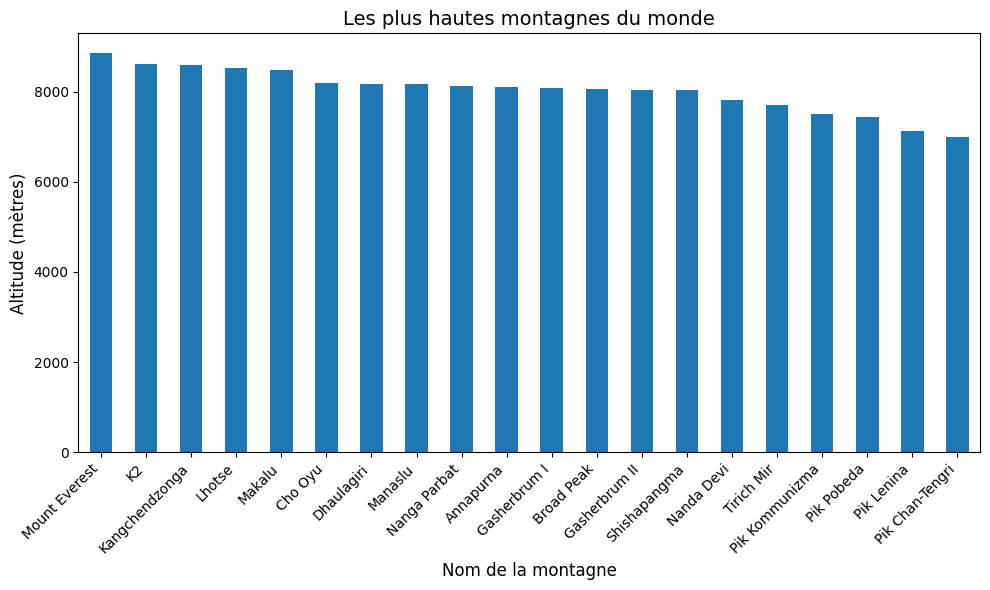

In [ ]:
# Exercice : Visualiser les 20 plus hautes montagnes du monde

# Votre code ici

## Importer et Exporter des fichiers CSV

Dans H2, deux fonctions permettent d'exporter et d'importer des tables au format CSV :

- **CSVWRITE** : génère un fichier CSV à partir du résultat d'une requête SQL.
- **CSVREAD** : lit un fichier CSV et retourne ses lignes sous forme de table virtuelle.

Ces fonctions sont invoquées comme des commandes SQL et peuvent être intégrées à des requêtes `SELECT` ou utilisées seules.

**Exemples**

```sql
-- exporter le contenu d'une table vers un fichier CSV
CALL CSVWRITE('csvfiles/Compte.csv', 'SELECT * FROM Compte');

-- importer un fichier CSV dans une table temporaire
SELECT * FROM CSVREAD('csvfiles/Compte.csv');
```

*Note : les chemins de fichiers sont relatifs au répertoire de travail du serveur H2 et les noms de colonnes sont déduits de la première ligne du CSV.*

In [ ]:
# Exporter toutes les tables de la base de données en fichiers CSV
cursor = db.cursor()
# Générer les commandes CSVWRITE pour chaque table
cursor.execute("SELECT 'CALL CSVWRITE(''csvfiles/' || TABLE_NAME || '.csv'', ''SELECT * FROM ' || TABLE_NAME || ''');' AS EXPORT_COMMAND FROM INFORMATION_SCHEMA.TABLES WHERE TABLE_SCHEMA = 'PUBLIC';")
commandes = cursor.fetchall()

# Exécuter chaque commande pour exporter les tables
for comm in commandes:  
    print(comm[0])
    cursor.execute(comm[0])
cursor.close()

Utilisation de `CSVREAD` pour créer une table

La fonction `CSVREAD()` peut être utilisée dans une clause `SELECT` pour lire les données d'un fichier CSV et les traiter comme une table temporaire. En combinaison avec `CREATE TABLE ... AS SELECT`, on peut directement importer le contenu d'un CSV dans une table de la base de données :

```sql
CREATE TABLE ma_table AS
SELECT * FROM CSVREAD('chemin/vers/fichier.csv');
```

Dans l'exemple suivant (Python), on parcourt tous les fichiers CSV d'un dossier, on utilise le nom du fichier pour déterminer le nom de la table, puis on exécute une commande SQL qui crée la table si elle n'existe pas déjà en important les données du fichier.

Ce mécanisme est pratique pour automatiser l'import de plusieurs fichiers CSV dans H2.

In [ ]:
# Importer les fichiers CSV dans des tables H2
# Le dossier contenant les fichiers CSV
dossier = "csvfiles"
cursor = db.cursor() 

# Parcourir tous les fichiers du dossier
for fichier in os.listdir(dossier):
    if fichier.endswith(".csv"):
        # Enlever l'extension .csv pour avoir le nom de la table
        nom_table = fichier[:-4].upper()
        chemin_complet = f"csvfiles/{fichier}"
        
        # Générer et exécuter les commandes SQL
        try:
            # D'abord, essayer de supprimer les données existantes
            commande_sql = f"DELETE FROM {nom_table}"
            cursor.execute(commande_sql)
            # Puis, importer les données du CSV
            commande_sql = f"INSERT INTO {nom_table} SELECT * FROM CSVREAD('{chemin_complet}')"
            cursor.execute(commande_sql)
            # Afficher le nombre de lignes importées
            commande_sql = f"SELECT '{nom_table}' AS TABLE_NAME, COUNT(*) AS CPT FROM {nom_table};"
            cursor.execute(commande_sql)
            afficher_format(cursor, "La table {} a été réinitialisé avec {} lignes.", ['TABLE_NAME', 'CPT'])
        except Exception as e:
            print(f"Erreur lors de l'importation du fichier {fichier}: {e}")
            print(f"Tentative de création de la table {nom_table} et réimportation du fichier {fichier}")
            try:
                # Créer la table à partir du CSV
                commande_sql = f"CREATE TABLE {nom_table} AS SELECT * FROM CSVREAD('{chemin_complet}');"
                cursor.execute(commande_sql)
                # Afficher le nombre de lignes créées
                commande_sql = f"SELECT '{nom_table}' AS TABLE_NAME, COUNT(*) AS CPT FROM {nom_table};"
                cursor.execute(commande_sql)
                afficher_format(cursor, "La table {} a été créée avec {} lignes.", ['TABLE_NAME', 'CPT'])
            except Exception as e:
                print(f"Erreur lors de la création de la table {nom_table}: {e}")   

# Valider les modifications
db.commit()
cursor.close()

## Exportation HTML complète
Ce script génère une page HTML structurée avec du CSS moderne et l'affiche directement sous la cellule !

Voir page pays.html

In [ ]:
# Générer une page HTML complète avec les informations géographiques
from IPython.display import display, HTML

"""
Exercice : Afficher les pays, leurs capitales, leur population et leur superficie dans une page HTML, 
avec une section pour chaque pays, et une sous-section pour les régions de chaque pays, avec les villes, 
les lacs et les montagnes de chaque région.
"""

# Ouvrir un fichier HTML pour écrire les résultats
outF = open('pays.html', 'w', encoding='utf-8')

# Écrire la structure HTML et le CSS
print('''<!DOCTYPE html>
<html>
<head>
    <meta charset="utf-8">
    <title>Résultat en HTML</title>
    <style>
        body { background-color: #f8f9fa; color: #333; margin: 40px; }
        h1 { color: #2c3e50; text-align: center; }
        table { width: 100%; }
        th, td { padding: 12px 15px; text-align: left; }
        th { background-color: #3498db; color: #ffffff; font-weight: bold; text-align: center; }
        tr { border-bottom: 1px solid #dddddd; }
        tr:nth-of-type(even) { background-color: #fbfbfb; }
        tr:hover { background-color: #f1f1f1; }
        td table { border: 1px solid #eee; }
        td table th { background-color: #7f8c8d; font-size: 0.9em; }
        td table td { padding: 6px 10px; font-size: 0.95em; }
        i { color: #e67e22; font-style: normal; font-weight: bold; }
        b { color: #2980b9; font-size: 1.1em; }
    </style>
</head>
<body>
''', file=outF)

# Titre principal
print('<h1><b>Les Pays</b></h1>', file=outF)
print('<table>', file=outF)

# Récupérer les données de la France et l'Italie
lespays = db.cursor()
lespays.execute("SELECT NAME,CODE,Capital,Area,Population FROM country WHERE name in ('France')")

# Traiter chaque pays
for pays in lespays.fetchall():
    code_pays = project_tuple(lespays, pays, ['CODE'])[0]
    # Afficher les informations du pays
    afficher_tuple(lespays, pays,
                   '<tr><td colspan="2"><b>{}</b> ({}) - Capitale: {}, Surface: {} km², Population: {} habitants</td></tr>', 
                   ['NAME', 'CODE', 'CAPITAL', 'AREA', 'POPULATION'], outF)    
    
    # Afficher les langues parlées
    leslangues = db.cursor()
    leslangues.execute("SELECT * FROM language WHERE Country = ?", code_pays)
    print("<tr><td colspan='2'>Langues parlées: ", file=outF)
    afficher_format(leslangues, "{0}, ", ['NAME'], outF)
    print("</td></tr>", file=outF)

    # Afficher les voisins
    lesvoisins = get_voisins(code_pays)
    print('<tr><th colspan="2">Les voisins</th></tr><tr><td colspan="2"><table>\n', file=outF)
    afficher_format(lesvoisins, "<tr><td width='30%'>{}</td><td>{} km de frontière</td></tr>", ['NOMVOISIN', 'LONGFRONT'], outF)
    print('</table></td></tr>\n', file=outF)

    # Afficher les régions avec leurs détails
    lesregions = get_regions(code_pays)
    print('<tr><th colspan="2">Les régions</th></tr>', file=outF)
    
    for region in lesregions.fetchall():
        nom_region = project_tuple(lesregions, region, ['NAME'])[0]
        print('<tr><td width="30%">', file=outF)
        # Afficher les infos de la région
        afficher_tuple(lesregions, region, "<b>{}</b><br><br>Capitale: {}<br>Surface: {} km²<br>Pop: {} hab.", 
                  ['NAME', 'CAPITAL', 'AREA', 'POPULATION'], outF)
        print('</td><td width="70%">', file=outF)
        
        # Afficher les villes de la région
        lesvilles = get_villes_region(code_pays, nom_region)
        print('<i>Les villes</i><table>\n', file=outF)
        afficher_format(lesvilles, "<tr><td width='30%'>{}</td><td>{} habitants</td></tr>", ['NAME', 'POPULATION'], outF)
        print('</table>\n', file=outF)
        lesvilles.close()
    
        # Afficher les lacs de la région
        leslacs = get_lacs_region(code_pays, nom_region)
        print('<i>Les lacs</i><table>\n', file=outF)
        afficher_format(leslacs, "<tr><td width='30%''>{}</td><td>{} km²</td><td>profondeur: {} m</td></tr>", ['NAME', 'AREA', 'DEPTH'], outF)
        print('</table>\n', file=outF)
        leslacs.close()

        # Afficher les montagnes de la région
        lesmontagnes = get_montagnes_region(code_pays, nom_region)
        print('<i>Les montagnes</i><table>\n', file=outF)
        afficher_format(lesmontagnes, "<tr><td width='30%'>{}</td><td>{} m</td></tr>", ['NAME', 'HEIGHT'], outF)
        print('</table>\n', file=outF)
        lesmontagnes.close()
                
        # Afficher les mers de la région
        lesmers = db.cursor()
        lesmers.execute("""
            SELECT s.Name, s.Depth 
            FROM Sea s JOIN geo_sea gs ON s.NAME = gs.Sea 
            WHERE gs.Country = ? AND gs.Province = ?
        """, [code_pays, nom_region])
        print('<i>Les mers</i><table>\n', file=outF)
        afficher_format(lesmers, "<tr><td width='30%'>{}</td><td>{} m de profondeur</td></tr>", ['NAME', 'DEPTH'], outF)
        print('</table>\n', file=outF)
        lesmers.close()

        # Afficher les rivières de la région
        lesrivieres = get_rivieres_region(code_pays, nom_region)
        print('<i>Les rivieres</i><table>\n', file=outF)
        afficher_format(lesrivieres, "<tr><td width='30%'>{}</td><td>{} km</td></tr>", ['NAME', 'LENGTH'], outF)
        print('</table>\n', file=outF)
        lesrivieres.close()

        print('</td></tr>\n', file=outF)
    
    lesregions.close()

lespays.close()
print('</table></body></html>', file=outF)
outF.close()

# Affichage direct du contenu HTML dans le notebook
with open('pays.html', 'r', encoding='utf-8') as f:
    html_content = f.read()
display(HTML(html_content))

In [ ]:
# Valider les modifications et fermer la connexion
db.commit()
# db.close()  # Décommenter pour fermer la connexion
